[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\33661\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Fichiers trouvés : 13
1999-05-17.xml → 1618652 caractères
1999-05-18.xml → 1562716 caractères
1999-05-19.xml → 1655481 caractères
1999-05-20.xml → 1576371 caractères
1999-05-21.xml → 1636622 caractères
1999-05-22.xml → 1732010 caractères
1999-05-23.xml → 1405556 caractères
1999-05-25.xml → 1505890 caractères
1999-05-26.xml → 1601444 caractères
1999-05-27.xml → 1565711 caractères
1999-05-29.xml → 1710412 caractères
1999-05-30.xml → 1603039 caractères
1999-05-31.xml → 1653680 caractères

13 documents chargés

Document: 1999-05-17.xml
  dã : 0.485
  rã : 0.337
  tã : 0.243
  prã : 0.192
  30 : 0.172
  re : 0.171
  plus : 0.137
  03 : 0.131
  lã : 0.128
  deux : 0.108
  15 : 0.107
  14 : 0.106
  nã : 0.105
  cette : 0.1
  mã : 0.099
  20 : 0.095
  18 : 0.094
  gã : 0.093
  tait : 0.092
  mai : 0.091
  ans : 0.086
  tout : 0.085
  12 : 0.082
  aprã : 0.079
  17 : 0.079
  rue : 0.076
  cã : 0.074
  bat : 0.074
  29 : 0.074
  sã : 0.073
  10 : 0.071
  pã : 0.069
  saint : 0.066
  tous : 0.063

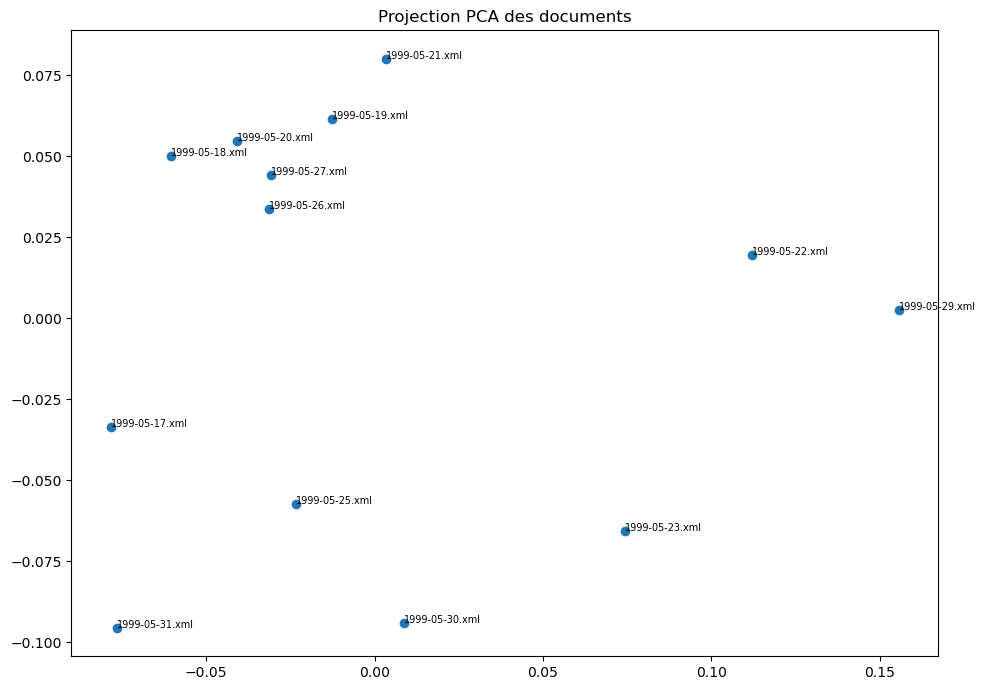

In [5]:
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os, glob
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# --- DIAGNOSTIC ---
folder_path = r"C:\Users\33661\Documents\ÉCOLE\TRADI\L3 - Paris IV\Master TAL\Cours\Séance 4\Corpus\Annee1999"
files = glob.glob(os.path.join(folder_path, "*.xml"))
print(f"Fichiers trouvés : {len(files)}")





# --- EXTRACTION ---
def extract_text(path):
    with open(path, "r", encoding="cp1252") as f:
        soup = BeautifulSoup(f, "xml")
        text = soup.get_text(separator=" ")
        return " ".join(text.split())

documents = []
filenames = []
for path in files:
    text = extract_text(path)
    print(f"{os.path.basename(path)} → {len(text)} caractères")  # diagnostic
    documents.append(text)
    filenames.append(os.path.basename(path))
print(f"\n{len(documents)} documents chargés")





# --- TFIDF ---
vectorizer = TfidfVectorizer(
    stop_words=stopwords.words('french'),  # fix : french n'est pas supporté nativement
    max_features=1000
)
text_clean = vectorizer.fit_transform(documents)

# --- TOP MOTS ---
feature_names = vectorizer.get_feature_names_out()
def top_words_per_doc(text_clean, feature_names, n=100):
    for i in range(text_clean.shape[0]):
        row = text_clean[i].toarray().flatten()
        top_indices = row.argsort()[-n:][::-1]
        print(f"\nDocument: {filenames[i]}")
        for idx in top_indices:
            print(f"  {feature_names[idx]} : {round(row[idx], 3)}")
top_words_per_doc(text_clean, feature_names)

# --- SIMILARITÉ ---
similarity_matrix = cosine_similarity(text_clean)
print("\nMatrice de similarité :")
print(np.round(similarity_matrix, 2))

# --- DOCUMENT LE PLUS PROCHE ---
for i in range(len(filenames)):
    similarities = similarity_matrix[i].copy()  # fix : .copy() pour ne pas modifier l'original
    similarities[i] = -1
    closest = similarities.argmax()
    print(f"{filenames[i]} est proche de {filenames[closest]}")

# --- PCA ---
pca = PCA(n_components=2)
text_clean_reduced = pca.fit_transform(text_clean.toarray())
plt.figure(figsize=(10, 7))
plt.scatter(text_clean_reduced[:, 0], text_clean_reduced[:, 1])
for i, name in enumerate(filenames):
    plt.annotate(name, (text_clean_reduced[i, 0], text_clean_reduced[i, 1]), fontsize=7)
plt.title("Projection PCA des documents")
plt.tight_layout()
plt.show()